<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/solution_03_bayes_theorem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gaussian Naive Bayesian alogorithm**
https://scikit-learn.org/stable/modules/naive_bayes.html
<img src = 'https://wikimedia.org/api/rest_v1/media/math/render/svg/d0d9f596ba491384422716b01dbe74472060d0d7'>

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

## **사전확률, 사후확률, 조건부 확률 로 구하기**
- Probability density function이 우도(likelihood)

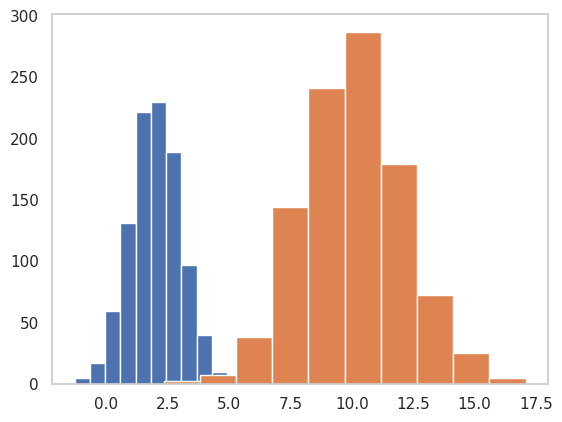

In [2]:
sns.set_style("whitegrid", {'axes.grid' : False})
mu_A, sigma_A = 2, 1
ax = plt.hist(np.random.normal(mu_A, sigma_A, size=(1000)))
mu_B, sigma_B = 10, 2
ax = plt.hist(np.random.normal(mu_B, sigma_B, size=(1000)))

In [3]:
import scipy
scipy.stats.norm(mu_A, sigma_A).pdf(2) # '2'를 관측하였을 경우 A분포의 우도
scipy.stats.norm(mu_B, sigma_B).pdf(2) # '2'를 관측하였을 경우 B분포의 우도

np.float64(0.3989422804014327)

np.float64(6.691511288244268e-05)

### 2. MAP (Maximum A posterior)
https://en.wikipedia.org/wiki/Naive_Bayes_classifier

In [4]:
df = pd.DataFrame({'Person' : ['male', 'male', 'male', 'male','female','female','female','female'],
                  'height (feet)' : [6, 5.92, 5.58, 5.92, 5, 5.5, 5.42, 5.75], # feet
                  'weight (lbs)' : [180, 190, 170, 165, 100, 150, 130, 150],  # pounds
                  'foot size (inches)' : [12, 11, 12, 10, 6, 8, 7, 9]})       # inches

df

,Person,height (feet),weight (lbs),foot size (inches)
0,male,6.00,180,12
1,male,5.92,190,11
2,male,5.58,170,12
3,male,5.92,165,10
4,female,5.00,100,6
5,female,5.50,150,8
6,female,5.42,130,7
7,female,5.75,150,9


In [5]:
data = df.groupby('Person')[['height (feet)', 'weight (lbs)', 'foot size (inches)']].agg(['mean','var'])
# Flatten MultiIndex columns
data.columns = ['_'.join(col).strip() for col in data.columns.values]
data = data.reset_index()
data

,Person,height (feet)_mean,height (feet)_var,weight (lbs)_mean,weight (lbs)_var,foot size (inches)_mean,foot size (inches)_var
0,female,5.4175,0.097225,132.50,558.333333,7.50,1.666667
1,male,5.8550,0.035033,176.25,122.916667,11.25,0.916667


### 신장(height), 단일변수만 고려할 경우는 남성일 가능성(사후확률)이 높다

### 단계 1. 남성과 여성의 각각 신장(Height)의 평균과 표준편차를 구하기

In [6]:
import scipy

mu_f, sigma_f = data.iloc[1,1], np.sqrt(data.iloc[1,2])
mu_m, sigma_m = data.iloc[0,1], np.sqrt(data.iloc[0,2])

print(f'여성의 신장(Height) : 평균 {mu_m}, 표준편차 {sigma_m}')
print('\n')
print(f'남성의 신장(Height) : 평균 {mu_f}, 표준편차 {sigma_f}')

여성의 신장(Height) : 평균 5.4175, 표준편차 0.31180923655337717


남성의 신장(Height) : 평균 5.855, 표준편차 0.18717193521821934


In [7]:
like_m = scipy.stats.norm(mu_f, sigma_f).pdf(6) # '6'를 관측하였을 경우 남성 키 분포의 우도
print(f'남성 우도는 {like_m}')

like_f = scipy.stats.norm(mu_m, sigma_m).pdf(6) # '6'를 관측하였을 경우 여성 키 분포의 우도
print(f'여성 우도는 {like_f}')

남성 우도는 1.5788831832641042
여성 우도는 0.2234587268448157


In [8]:
print(f'여성 우도는 {like_f}')

여성 우도는 0.2234587268448157


### 즉 키가 6 feet이면 남자일 가능성이 여성일 경우보다 높다. 따라서 남성이다.

### 남년 총 10개이지만 표본데이터로 연속확률밀도함수를 그리면


단계 2. 신장(Height)이 6 feet 일 경우 남성과 여성의 확률밀도함수(Likelihood)
- 5개의 데이터가 평균과 분산을 가진 정규분포라고 가정하면,

Text(6.2, 2.078883183264104, 'Male Likelihood: 1.5789')

Text(6.2, 0.7234587268448157, 'Male Likelihood: 0.2235')

Text(0.5, 1.0, 'Height Distribution (Female vs Male)')

Text(0.5, 0, 'Height (feet)')

Text(0, 0.5, 'Probability Density')

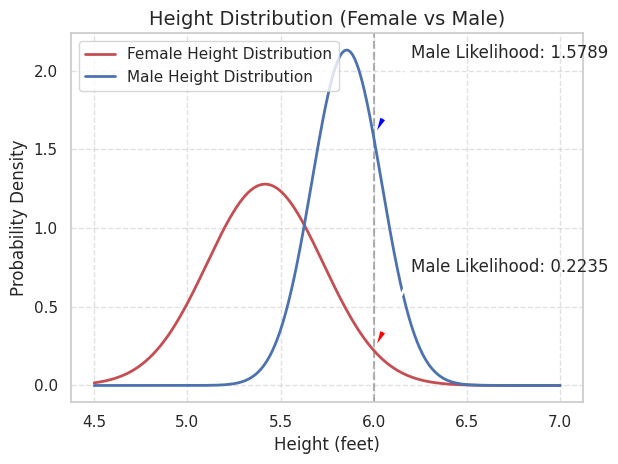

In [9]:
from scipy.stats import norm

target_height = 6

# x축 범위 설정 (키 4.5ft ~ 7ft)
x = np.linspace(4.5, 7, 500)

# 6피트 지점 표시 및 화살표 추가
plt.axvline(x=target_height, color='gray', linestyle='--', alpha=0.6)
# 남성 정규분포 곡선 그리기 (mu_m, sigma_m은 여성의 평균과 표준편차입니다)
plt.plot(x, norm.pdf(x, mu_m, sigma_m), 'r-', label='Female Height Distribution', linewidth=2)
# 여성 정규분포 곡선 그리기 (mu_f, sigma_f는 남성의 평균과 표준편차입니다)
plt.plot(x, norm.pdf(x, mu_f, sigma_f), 'b-', label='Male Height Distribution', linewidth=2)

# 그림에 likelihood 텍스트 표시하기
plt.annotate(f'Male Likelihood: {like_m:.4f}',
             xy=(target_height, like_m), xytext=(target_height + 0.2, like_m + 0.5),
             arrowprops=dict(facecolor='blue', shrink=0.05, width=1, headwidth=5))

plt.annotate(f'Male Likelihood: {like_f:.4f}',
             xy=(target_height, like_f), xytext=(target_height + 0.2, like_f + 0.5),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5))

# 그래프 설정
plt.title('Height Distribution (Female vs Male)', fontsize=14)
plt.xlabel('Height (feet)', fontsize=12); plt.ylabel('Probability Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
from scipy.stats import norm
import numpy as np

# New individual's features
new_height = 6
new_weight = 130
new_foot_size = 8

# Prior probabilities (assuming equal prior for simplicity, based on 4 males and 4 females in original df)
p_prior_male = 0.5
p_prior_female = 0.5

# Female parameters from 'data' DataFrame
female_params = data.loc[data['Person'] == 'female'].iloc[0]
female_height_mean, female_height_var = female_params['height (feet)_mean'], female_params['height (feet)_var']
female_weight_mean, female_weight_var = female_params['weight (lbs)_mean'], female_params['weight (lbs)_var']
female_foot_size_mean, female_foot_size_var = female_params['foot size (inches)_mean'], female_params['foot size (inches)_var']

# Male parameters from 'data' DataFrame
male_params = data.loc[data['Person'] == 'male'].iloc[0]
male_height_mean, male_height_var = male_params['height (feet)_mean'], male_params['height (feet)_var']
male_weight_mean, male_weight_var = male_params['weight (lbs)_mean'], male_params['weight (lbs)_var']
male_foot_size_mean, male_foot_size_var = male_params['foot size (inches)_mean'], male_params['foot size (inches)_var']

# Calculate likelihoods for female
likelihood_female_height = norm.pdf(new_height, female_height_mean, np.sqrt(female_height_var))
likelihood_female_weight = norm.pdf(new_weight, female_weight_mean, np.sqrt(female_weight_var))
likelihood_female_foot_size = norm.pdf(new_foot_size, female_foot_size_mean, np.sqrt(female_foot_size_var))

# Calculate likelihoods for male
likelihood_male_height = norm.pdf(new_height, male_height_mean, np.sqrt(male_height_var))
likelihood_male_weight = norm.pdf(new_weight, male_weight_mean, np.sqrt(male_weight_var))
likelihood_male_foot_size = norm.pdf(new_foot_size, male_foot_size_mean, np.sqrt(male_foot_size_var))

# Calculate unnormalized posterior probabilities
unnormalized_posterior_female = likelihood_female_height * likelihood_female_weight * likelihood_female_foot_size * p_prior_female
unnormalized_posterior_male = likelihood_male_height * likelihood_male_weight * likelihood_male_foot_size * p_prior_male

# Calculate evidence (P(X))
evidence = unnormalized_posterior_female + unnormalized_posterior_male

# Calculate normalized posterior probabilities
posterior_female = unnormalized_posterior_female / evidence
posterior_male = unnormalized_posterior_male / evidence

print(f"새로운 관측치 (신장: {new_height} 피트, 체중: {new_weight} 파운드, 발크기: {new_foot_size} 인치)에 대한 사후확률:")
print(f"여성일 사후확률: {posterior_female:.5f}")
print(f"남성일 사후확률: {posterior_male:.5f}")

새로운 관측치 (신장: 6 피트, 체중: 130 파운드, 발크기: 8 인치)에 대한 사후확률:
여성일 사후확률: 0.99999
남성일 사후확률: 0.00001


### 신장(height), 체중, 발크기 등 다변량을 고려할 경우는 여성일 가능성(사후확률)이 높다

## **2. Scikit-Learn의 GaussianNB로 성별을 분별하기**

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn import preprocessing
X= df.iloc[0:8, 1:4]
y= preprocessing.LabelBinarizer().fit_transform(df.iloc[0:8, 0]) # 남성 '0', 여성 '1'
model = GaussianNB()
model.fit(X, y)
model.predict([[6,13,8]]) # reshape(-1,1)
model.predict_proba([[6,13,8]])

GaussianNB()

array([0])

array([[1.00000000e+00, 7.14378768e-58]])

## **3. Gaussian Naive Bayes Excercise**

### 의사결정경계선이 곡선으로 나타나고 예측 확률은 '0', '1'에 편중하여 생성

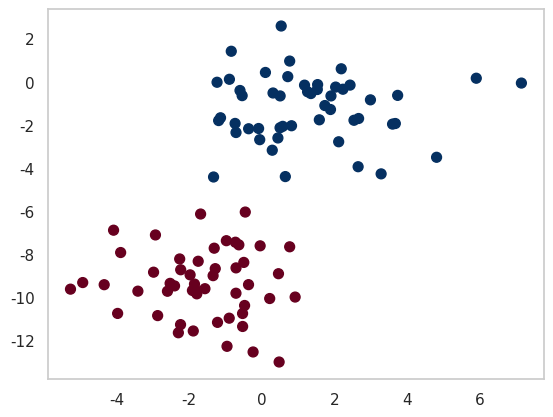

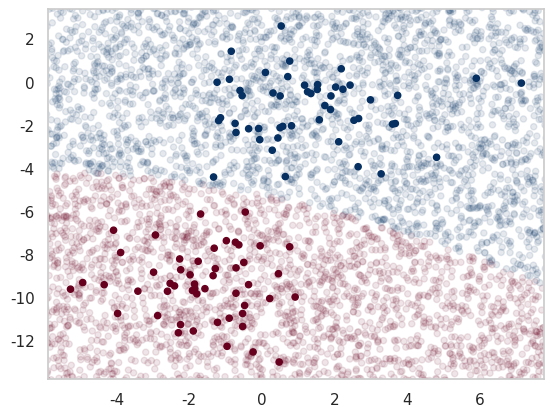

In [12]:
from sklearn.datasets import make_blobs
plt.rcParams['axes.unicode_minus'] = False
X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu');plt.show()

from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X, y);

rng = np.random.RandomState(0)
Xnew = [-6, -14] + [14, 18] * rng.rand(5000, 2)
ynew= model.predict(Xnew)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap='RdBu')
lim = plt.axis()
plt.scatter(Xnew[:, 0], Xnew[:, 1], c=ynew, s=20, cmap='RdBu', alpha=0.1)
plt.axis(lim);

(array([2086.,   66.,   37.,   35.,   42.,   32.,   44.,   43.,   66.,
        2549.]),
 array([3.0043337e-16, 1.0000000e-01, 2.0000000e-01, 3.0000000e-01,
        4.0000000e-01, 5.0000000e-01, 6.0000000e-01, 7.0000000e-01,
        8.0000000e-01, 9.0000000e-01, 1.0000000e+00]),
 <BarContainer object of 10 artists>)

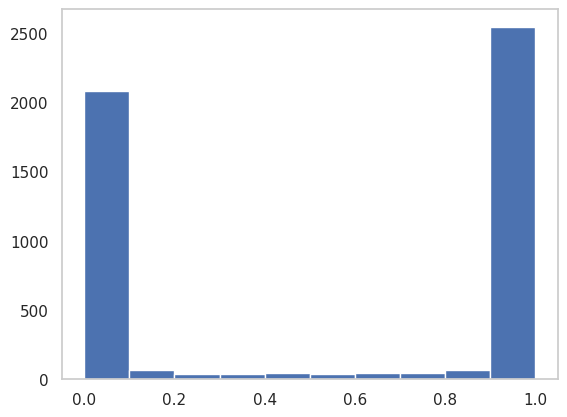

In [13]:
yprob = model.predict_proba(Xnew)
plt.hist(yprob[:, 1])

### 베이지안 이론에서 확률이란 관측된 사실(데이터)에 따라 변화되는 신념(credibility)
<img src='https://miro.medium.com/max/1400/1*t6Ma32W2rGd2FOfFkSyxFA.png'>

## **4. Text mining with GNB**

In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.model_selection import KFold, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report # Removed plot_roc_curve, plot_confusion_matrix

from sklearn.pipeline import Pipeline, make_pipeline
# 모델저장
from joblib import dump, load

In [15]:
corpus = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is this the first document?',
]
df = pd.DataFrame(corpus, columns=['content'])
df

,content
0,This is the first document.
1,This document is the second document.
2,And this is the third one.
3,Is this the first document?


In [16]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus) # X = vectorizer.fit_transform(df['content'])
print(vectorizer.get_feature_names_out())
print(X.toarray())

data = pd.DataFrame(X.toarray(), columns = vectorizer.get_feature_names_out())
data

['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
[[0 1 1 1 0 0 1 0 1]
 [0 2 0 1 0 1 1 0 1]
 [1 0 0 1 1 0 1 1 1]
 [0 1 1 1 0 0 1 0 1]]


,and,document,first,is,one,second,the,third,this
0,0,1,1,1,0,0,1,0,1
1,0,2,0,1,0,1,1,0,1
2,1,0,0,1,1,0,1,1,1
3,0,1,1,1,0,0,1,0,1


TF–IDF
- CountVectorizer 방식의 단점은 너무 자주 나오는 단어에 가중치가 높아져 sub-optimal in some classification algorithms.
- 이러한 점을 보완하기 위해 *term frequency-inverse document frequency* (*TF–IDF*)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer()
X = vec.fit_transform(corpus)
pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,and,document,first,is,one,second,the,third,this
0,0.000000,0.469791,0.580286,0.384085,0.000000,0.000000,0.384085,0.000000,0.384085
1,0.000000,0.687624,0.000000,0.281089,0.000000,0.538648,0.281089,0.000000,0.281089
2,0.511849,0.000000,0.000000,0.267104,0.511849,0.000000,0.267104,0.511849,0.267104
3,0.000000,0.469791,0.580286,0.384085,0.000000,0.000000,0.384085,0.000000,0.384085


## 5. Multinomial Naive Bayes
###  Example: Classifying Text

- text classification에 종종 사용
- 단어의 출현빈도가 특성변수와 관련
- 20 Newsgroups corpus를 사용하여 3개의 그룹으로 분류하는 방법

In [18]:
from sklearn.datasets import fetch_20newsgroups
data = fetch_20newsgroups()
data.keys()
df = pd.DataFrame(data['data'], columns= ['content'])
df['target'] = pd.Series(data.target)
convert = dict(zip(np.arange(len(data.target_names)), data.target_names, ))
df['categories'] = df['target'].map(convert)
df.head()
df.shape

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])

,content,target,categories
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,7,rec.autos
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4,comp.sys.mac.hardware
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4,comp.sys.mac.hardware
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,1,comp.graphics
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14,sci.space


(11314, 3)

Here is a representative entry from the data:

In [19]:
categories = ['talk.religion.misc', 'soc.religion.christian', 'sci.space', 'comp.graphics']
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)
print(f'corpus의 자료형태는 : {type(train.data)}')
print(train.data[5])

corpus의 자료형태는 : <class 'list'>
From: dmcgee@uluhe.soest.hawaii.edu (Don McGee)
Subject: Federal Hearing
Originator: dmcgee@uluhe
Organization: School of Ocean and Earth Science and Technology
Distribution: usa
Lines: 10


Fact or rumor....?  Madalyn Murray O'Hare an atheist who eliminated the
use of the bible reading and prayer in public schools 15 years ago is now
going to appear before the FCC with a petition to stop the reading of the
Gospel on the airways of America.  And she is also campaigning to remove
Christmas programs, songs, etc from the public schools.  If it is true
then mail to Federal Communications Commission 1919 H Street Washington DC
20054 expressing your opposition to her request.  Reference Petition number

2493.



### TF-IDF vectorizer와 multinomial naive Bayes classifier를 를 pipeline으로 구성

파이프라인을 데이터에 적용하여 예측하면

- test data의 레이블을 예측하고 실제 자료의 레이블과 confusion matrix를 확인하면

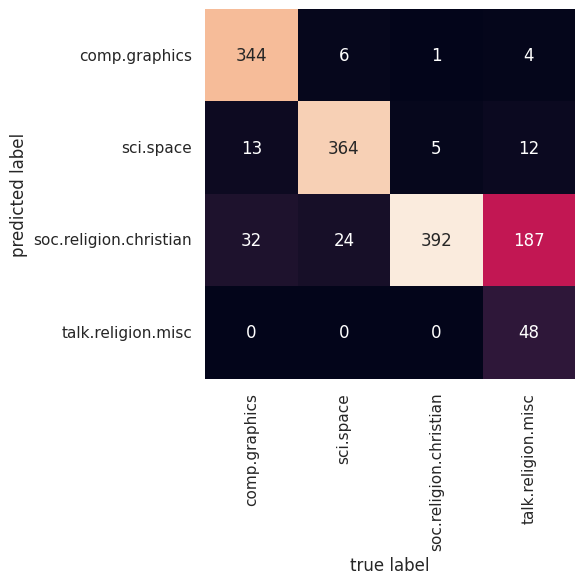

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

model = make_pipeline(TfidfVectorizer(), MultinomialNB())

model.fit(train.data, train.target)
labels = model.predict(test.data)

from sklearn.metrics import confusion_matrix
mat = confusion_matrix(test.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train.target_names, yticklabels=train.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

##  <font color='red'> 각 단어의 빈도로 예측이 거의 완벽
### 모든 naive algorithm은 대용량 high-dimensional text 자료에 잘 사용할 경우 언비리버블하게 잘 예측한다
### 예측 반복작업을 함수로 만들어

Let's try it out:

In [21]:
def predict_category(s, train=train, model=model):
    pred = model.predict([s])
    return train.target_names[pred[0]]

predict_category('The Russian rocket agency is expected to')
predict_category('Worship like a pop at the Shrine of Your Lies')

'sci.space'

'soc.religion.christian'

### 새로운 값(text)를 예측해보자

In [22]:
train.keys()

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])

In [23]:
model.predict(['I am a robot cop.'])
y_pred = model.predict(['I am a robot cop.'])
train.target_names
train.target_names[y_pred[0]]

array([2])

['comp.graphics', 'sci.space', 'soc.religion.christian', 'talk.religion.misc']

'soc.religion.christian'

## Data centric or model centric?
### 데이터의 특성에 따라 예측을 잘하는 알고리즘이 있음

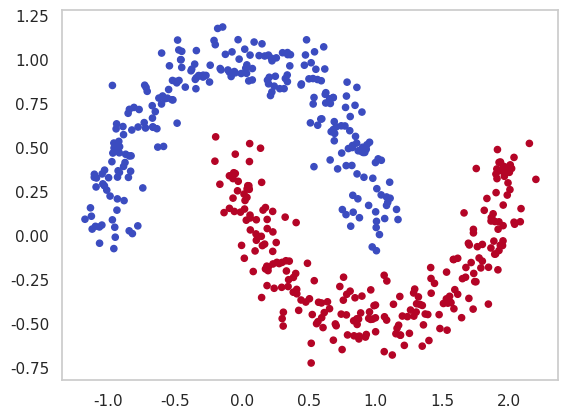

In [24]:
from sklearn.datasets import make_moons, make_circles, make_classification
X, y = make_moons(n_samples=500, noise=0.1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap='coolwarm');

Text(0.5, 1.0, 'KNeighborsClassifier()')

Text(0.5, 1.0, 'GaussianNB()')

Text(0.5, 1.0, 'SGDClassifier()')

Text(0.5, 1.0, 'LogisticRegression()')

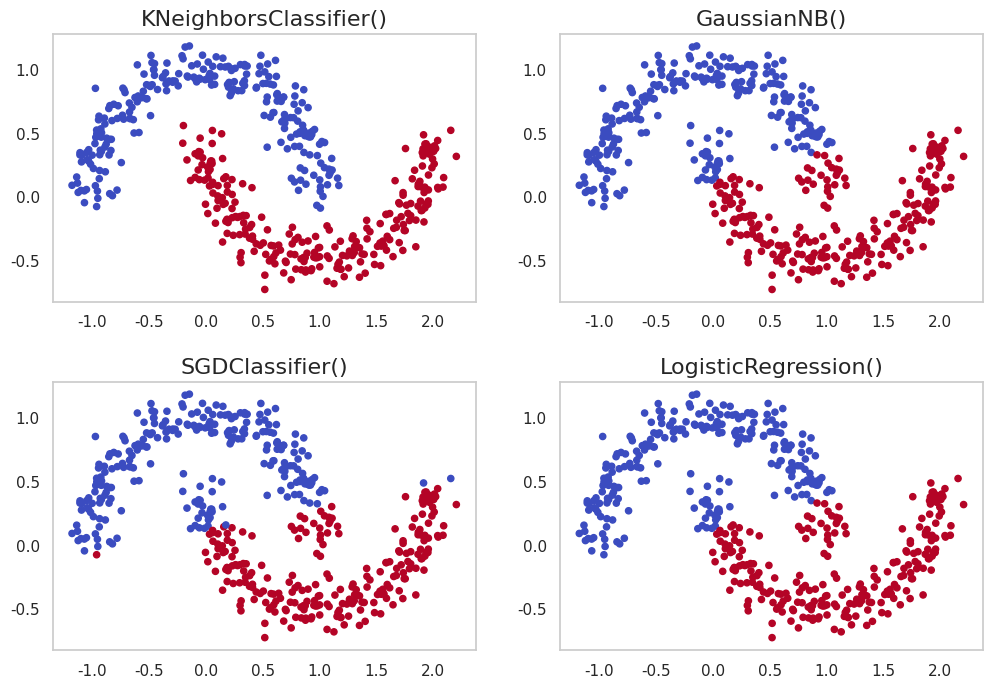

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression

fig, axs = plt.subplots(2,2, figsize=(12, 8), facecolor='w', edgecolor='k')
fig.subplots_adjust(hspace = .3, wspace=.2)
axs = axs.ravel()
classifiers = [KNeighborsClassifier(), GaussianNB(),
               SGDClassifier(), LogisticRegression()]
for i, classifier in enumerate(classifiers) :
    axs[i].set_title(str(classifier), fontsize='16')
    y_pred = classifier.fit(X, y).predict(X)
    axs[i].scatter(X[:, 0], X[:, 1], c=y_pred, s=20, cmap='coolwarm')

# END